<a href="https://colab.research.google.com/github/DIV807/Consumer-Credit-Card-Default-Prediction/blob/main/ConsumerCreditCardDefaultPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Install Libraries

In [ ]:
!pip install xgboost shap imbalanced-learn


In [ ]:
!pip install xgboost shap


In [ ]:
!pip install imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns


# Dataset 1 – Taiwan Credit

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving UCI_Credit_Card.xls to UCI_Credit_Card.xls


In [ ]:
import pandas as pd

data = pd.read_excel("UCI_Credit_Card.xls", header=1)

print(data.shape)
data.head()


(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
data.drop("ID", axis=1, inplace=True)

print(data.shape)


(30000, 24)


In [ ]:
X = data.drop("default payment next month", axis=1)
y = data["default payment next month"]


In [ ]:
y.value_counts()


,count
default payment next month,
0,23364
1,6636


model training

In [ ]:
# Utilization ratio
data["UTIL_RATIO"] = data["BILL_AMT1"] / (data["LIMIT_BAL"] + 1)

# Total bill pressure
data["TOTAL_BILL"] = data[[
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"
]].sum(axis=1)

# Total payment capacity
data["TOTAL_PAY"] = data[[
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]].sum(axis=1)

# Payment behavior score
data["PAY_SCORE"] = data[[
    "PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"
]].mean(axis=1)

# Bill to limit stress
data["BILL_TO_LIMIT"] = data["TOTAL_BILL"] / (data["LIMIT_BAL"] + 1)


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop("default payment next month", axis=1)
y = data["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


First Model — Logistic Regression (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))


              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

ROC-AUC: 0.7100597622571971


Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC: 0.7576042106274867


XG Boost

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [ ]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=4,
    gamma=0.1,
    scale_pos_weight=3.5,
    eval_metric='logloss',
    random_state=42
)

xgb_tuned.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_tuned.fit(X_train, y_train)

y_pred = xgb_tuned.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.49      0.55      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.69      0.69      6000
weighted avg       0.78      0.77      0.78      6000

ROC-AUC: 0.76999521534264


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_tuned,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())


Cross-validation ROC-AUC scores: [0.78162699 0.77078258 0.77312532 0.77742385 0.77004472]
Mean ROC-AUC: 0.7746006926132585


Explainable AI

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.49      0.55      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.69      0.69      6000
weighted avg       0.78      0.77      0.78      6000

ROC-AUC: 0.76999521534264


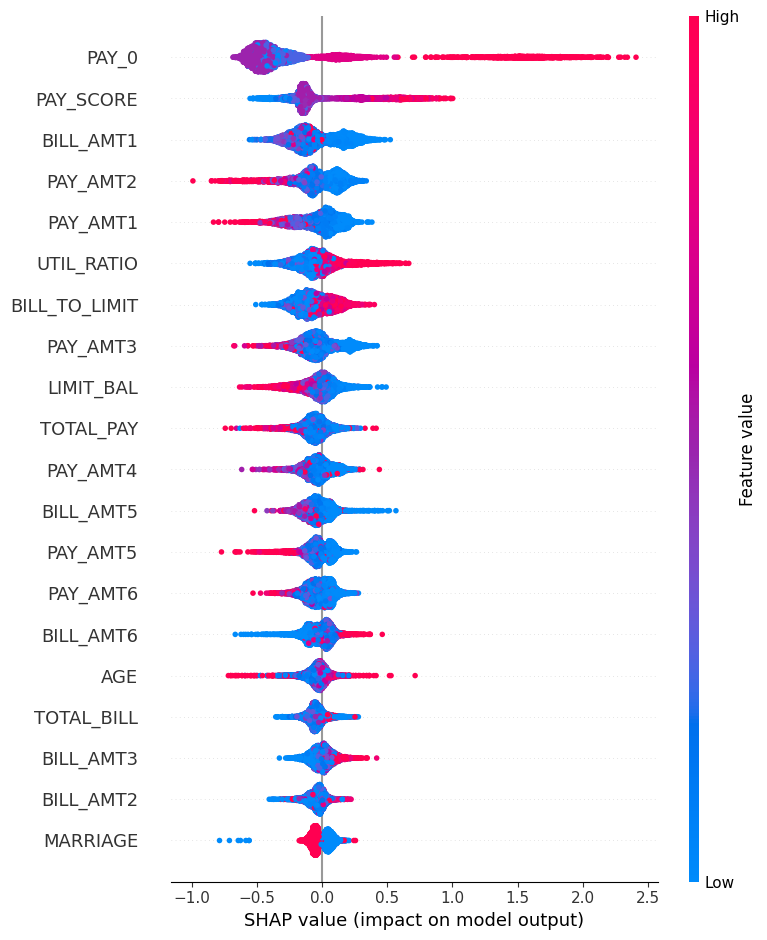

In [ ]:
from xgboost import XGBClassifier
import shap

xgb_tuned = XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=4,
    gamma=0.1,
    scale_pos_weight=3.5,
    eval_metric='logloss',
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

y_pred = xgb_tuned.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:,1]))

# SHAP
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


Risk Segmentation using Probabilities

In [ ]:
probs = xgb_tuned.predict_proba(X_test)[:,1]


In [ ]:
risk_level = []

for p in probs:
    if p < 0.30:
        risk_level.append("Low Risk")
    elif p < 0.60:
        risk_level.append("Medium Risk")
    else:
        risk_level.append("High Risk")


In [ ]:
probs = xgb_tuned.predict_proba(X_test)[:,1]

risk_level = []
for p in probs:
    if p < 0.3:
        risk_level.append("Low")
    elif p < 0.7:
        risk_level.append("Medium")
    else:
        risk_level.append("High")

results = pd.DataFrame()
results["Actual"] = y_test.values
results["Default_Prob"] = probs
results["Risk_Level"] = risk_level

results.head()


,Actual,Default_Prob,Risk_Level
0,0,0.298940,Low
1,0,0.375659,Medium
2,0,0.421882,Medium
3,1,0.191700,Low
4,0,0.017189,Low


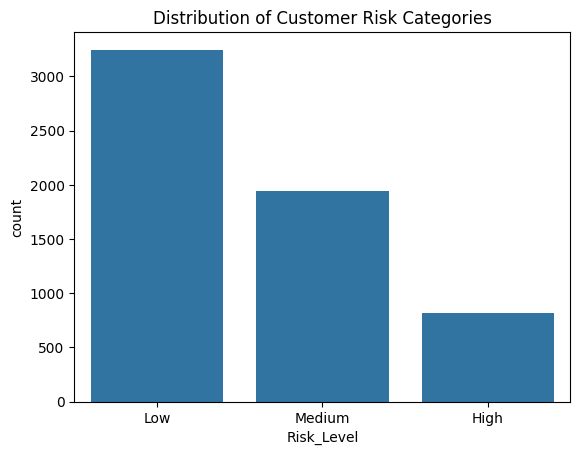

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=results["Risk_Level"])
plt.title("Distribution of Customer Risk Categories")
plt.show()


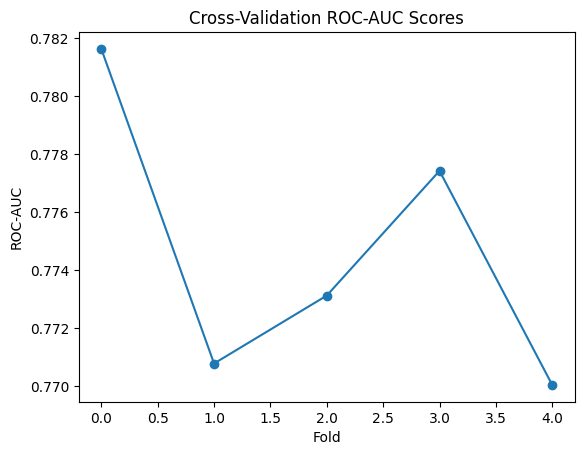

In [ ]:
import matplotlib.pyplot as plt

plt.plot(cv_scores, marker='o')
plt.title("Cross-Validation ROC-AUC Scores")
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.show()


# Dataset 2 – German Credit

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving german.data-numeric to german.data-numeric


In [ ]:
data_german = pd.read_csv(
    "german.data-numeric",
    delim_whitespace=True,
    header=None
)

data_german.head()


/tmp/ipython-input-1953522543.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_german = pd.read_csv(


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [ ]:
columns = [f"Feature_{i}" for i in range(1, 25)] + ["Target"]
data_german.columns = columns


In [ ]:
data_german["Target"] = data_german["Target"].apply(lambda x: 1 if x == 2 else 0)


In [ ]:
X_g = data_german.drop("Target", axis=1)
y_g = data_german["Target"]


In [ ]:
print(data_german.shape)


(1000, 25)


Train models

In [ ]:
from sklearn.model_selection import train_test_split

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_g, y_g,
    test_size=0.2,
    stratify=y_g,
    random_state=42
)


Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

scaler = StandardScaler()

X_train_g_scaled = scaler.fit_transform(X_train_g)
X_test_g_scaled = scaler.transform(X_test_g)

log_g = LogisticRegression(max_iter=1000)
log_g.fit(X_train_g_scaled, y_train_g)

pred = log_g.predict(X_test_g_scaled)

print(classification_report(y_test_g, pred))
print("ROC-AUC:", roc_auc_score(y_test_g, log_g.predict_proba(X_test_g_scaled)[:,1]))


              precision    recall  f1-score   support

           0       0.80      0.89      0.84       140
           1       0.66      0.48      0.56        60

    accuracy                           0.77       200
   macro avg       0.73      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200

ROC-AUC: 0.82


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_g = RandomForestClassifier(n_estimators=200, random_state=42)
rf_g.fit(X_train_g, y_train_g)

pred = rf_g.predict(X_test_g)

print(classification_report(y_test_g, pred))
print("ROC-AUC:", roc_auc_score(y_test_g, rf_g.predict_proba(X_test_g)[:,1]))


              precision    recall  f1-score   support

           0       0.81      0.92      0.86       140
           1       0.72      0.48      0.58        60

    accuracy                           0.79       200
   macro avg       0.77      0.70      0.72       200
weighted avg       0.78      0.79      0.78       200

ROC-AUC: 0.7928571428571429


XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_g = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb_g.fit(X_train_g, y_train_g)

pred = xgb_g.predict(X_test_g)

print(classification_report(y_test_g, pred))
print("ROC-AUC:", roc_auc_score(y_test_g, xgb_g.predict_proba(X_test_g)[:,1]))


              precision    recall  f1-score   support

           0       0.81      0.88      0.84       140
           1       0.65      0.52      0.57        60

    accuracy                           0.77       200
   macro avg       0.73      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200

ROC-AUC: 0.8001190476190476


SHAP (Explainability)

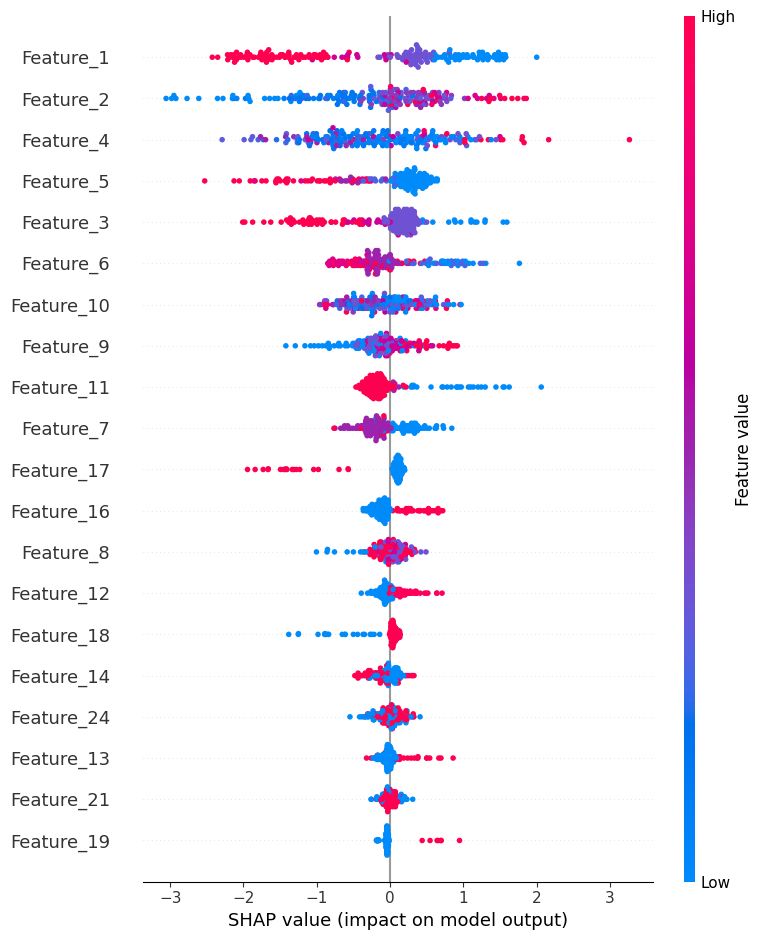

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_g)
shap_values = explainer.shap_values(X_test_g)

shap.summary_plot(shap_values, X_test_g)


# DATASET 3 — Give Me Some Credit

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cs-training.csv to cs-training.csv


In [ ]:
import pandas as pd

data_kaggle = pd.read_csv("cs-training.csv")

data_kaggle.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
data_kaggle.drop("Unnamed: 0", axis=1, inplace=True)


In [ ]:
data_kaggle.isnull().sum()


,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [ ]:
data_kaggle["MonthlyIncome"].fillna(
    data_kaggle["MonthlyIncome"].median(),
    inplace=True
)

data_kaggle["NumberOfDependents"].fillna(
    data_kaggle["NumberOfDependents"].median(),
    inplace=True
)


/tmp/ipython-input-673037479.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_kaggle["MonthlyIncome"].fillna(
/tmp/ipython-input-673037479.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method

In [ ]:
data_kaggle.isnull().sum()


,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [ ]:
X_k = data_kaggle.drop("SeriousDlqin2yrs", axis=1)
y_k = data_kaggle["SeriousDlqin2yrs"]


Train models

In [ ]:
from sklearn.model_selection import train_test_split

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_k, y_k,
    test_size=0.2,
    stratify=y_k,
    random_state=42
)


Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

scaler = StandardScaler()

X_train_k_scaled = scaler.fit_transform(X_train_k)
X_test_k_scaled = scaler.transform(X_test_k)

log_k = LogisticRegression(max_iter=1000)
log_k.fit(X_train_k_scaled, y_train_k)

pred = log_k.predict(X_test_k_scaled)

print(classification_report(y_test_k, pred))
print("ROC-AUC:", roc_auc_score(y_test_k, log_k.predict_proba(X_test_k_scaled)[:,1]))


              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000

ROC-AUC: 0.7143274515978317


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_k = RandomForestClassifier(n_estimators=200, random_state=42)
rf_k.fit(X_train_k, y_train_k)

pred = rf_k.predict(X_test_k)

print(classification_report(y_test_k, pred))
print("ROC-AUC:", roc_auc_score(y_test_k, rf_k.predict_proba(X_test_k)[:,1]))


              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.56      0.19      0.28      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000

ROC-AUC: 0.8472166164335544


XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_k = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=10,
    eval_metric='logloss'
)


xgb_k.fit(X_train_k, y_train_k)

pred = xgb_k.predict(X_test_k)

print(classification_report(y_test_k, pred))
print("ROC-AUC:", roc_auc_score(y_test_k, xgb_k.predict_proba(X_test_k)[:,1]))


              precision    recall  f1-score   support

           0       0.97      0.87      0.92     27995
           1       0.27      0.66      0.38      2005

    accuracy                           0.86     30000
   macro avg       0.62      0.77      0.65     30000
weighted avg       0.93      0.86      0.88     30000

ROC-AUC: 0.8580009611620172


In [ ]:
probs = xgb_k.predict_proba(X_test_k)[:,1]


In [ ]:
import numpy as np

pred_30 = (probs > 0.30).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test_k, pred_30))


              precision    recall  f1-score   support

           0       0.98      0.73      0.84     27995
           1       0.18      0.82      0.30      2005

    accuracy                           0.74     30000
   macro avg       0.58      0.78      0.57     30000
weighted avg       0.93      0.74      0.80     30000



In [ ]:
pred_20 = (probs > 0.20).astype(int)
print(classification_report(y_test_k, pred_20))


              precision    recall  f1-score   support

           0       0.99      0.63      0.77     27995
           1       0.15      0.90      0.25      2005

    accuracy                           0.64     30000
   macro avg       0.57      0.76      0.51     30000
weighted avg       0.93      0.64      0.73     30000



# SHAP

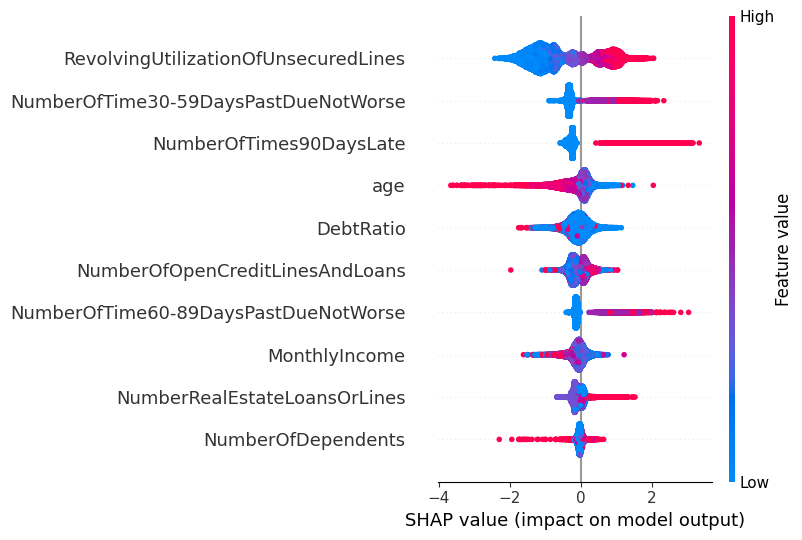

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_k)
shap_values = explainer.shap_values(X_test_k)

shap.summary_plot(shap_values, X_test_k)


In [ ]:
# Age-based fairness
data_kaggle["AgeGroup"] = pd.cut(
    data_kaggle["age"],
    bins=[0,30,45,60,100],
    labels=["Young","Mid","Senior","Elder"]
)

results = X_test_k.copy()
results["Actual"] = y_test_k.values
results["Pred"] = pred_30
results["AgeGroup"] = data_kaggle.loc[X_test_k.index,"AgeGroup"]

results.groupby("AgeGroup")[["Actual","Pred"]].mean()


/tmp/ipython-input-3662164311.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby("AgeGroup")[["Actual","Pred"]].mean()


,Actual,Pred
AgeGroup,,
Young,0.128531,0.531544
Mid,0.094969,0.434863
Senior,0.066598,0.318814
Elder,0.027273,0.109424


In [ ]:
# ==============================
# FAIRNESS MITIGATION
# ==============================

import numpy as np
from sklearn.metrics import recall_score

# Convert age into protected groups
X_train_fair = X_train.copy()
X_test_fair = X_test.copy()

X_train_fair["age_group"] = (X_train["AGE"] >= 35).astype(int)
X_test_fair["age_group"]  = (X_test["AGE"] >= 35).astype(int)

# ------------------------------
# BEFORE fairness metrics
# ------------------------------
probs_before = xgb_tuned.predict_proba(X_test)[:,1]
pred_before = (probs_before >= 0.5).astype(int)

young = X_test_fair["age_group"] == 0
old   = X_test_fair["age_group"] == 1

dp_young = pred_before[young].mean()
dp_old   = pred_before[old].mean()

demographic_parity_before = abs(dp_young - dp_old)

recall_young = recall_score(y_test[young], pred_before[young])
recall_old   = recall_score(y_test[old], pred_before[old])
equal_opp_before = abs(recall_young - recall_old)

# ------------------------------
# MITIGATION: Reweight training samples
# ------------------------------
weights = np.where(X_train["AGE"] < 35, 1.2, 1.0)

xgb_fair = XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=4,
    gamma=0.1,
    scale_pos_weight=3.5
)

xgb_fair.fit(X_train, y_train, sample_weight=weights)

# AFTER fairness
probs_after = xgb_fair.predict_proba(X_test)[:,1]
pred_after = (probs_after >= 0.5).astype(int)

dp_young_after = pred_after[young].mean()
dp_old_after   = pred_after[old].mean()
demographic_parity_after = abs(dp_young_after - dp_old_after)

recall_young_after = recall_score(y_test[young], pred_after[young])
recall_old_after   = recall_score(y_test[old], pred_after[old])
equal_opp_after = abs(recall_young_after - recall_old_after)

print("Before:", demographic_parity_before, equal_opp_before)
print("After:", demographic_parity_after, equal_opp_after)


Before: 0.015486323098967497 0.029523567017996966
After: 0.010686688929351457 0.02220292280130587


Predicted probability: 0.9882344
Actual label: 1


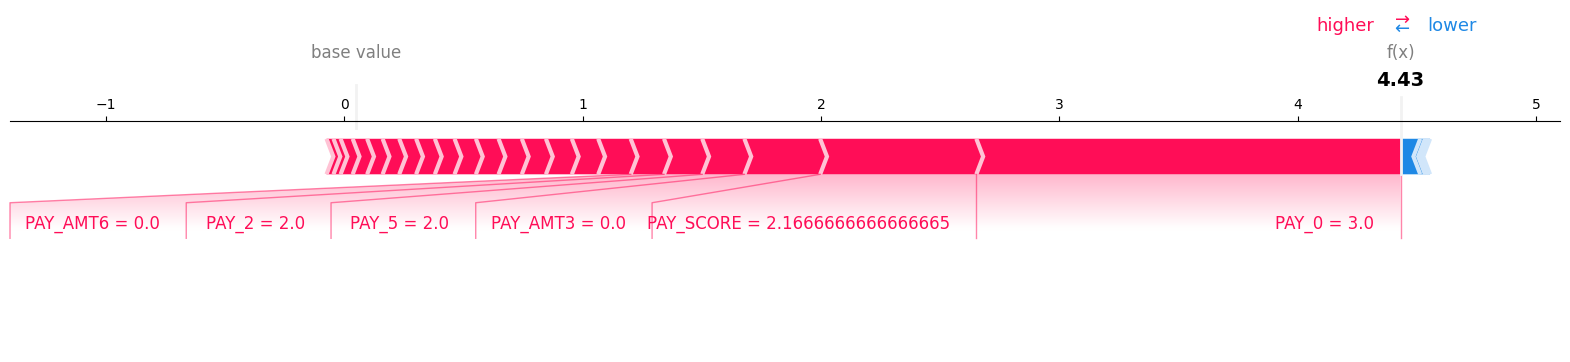

In [ ]:
# ==============================
# SHAP CASE STUDY
# ==============================

import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# pick a high-risk customer
idx = np.argmax(probs_before)

print("Predicted probability:", probs_before[idx])
print("Actual label:", y_test.iloc[idx])

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)


In [ ]:
# ==============================
# BUSINESS IMPACT SIMULATION
# ==============================

# assume:
# False negative cost = 5x
# False positive cost = 1x

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_before)

TN, FP, FN, TP = cm.ravel()

cost_before = FP*1 + FN*5

cm_after = confusion_matrix(y_test, pred_after)
TN2, FP2, FN2, TP2 = cm_after.ravel()

cost_after = FP2*1 + FN2*5

print("Estimated financial risk BEFORE:", cost_before)
print("Estimated financial risk AFTER:", cost_after)


Estimated financial risk BEFORE: 3728
Estimated financial risk AFTER: 3678


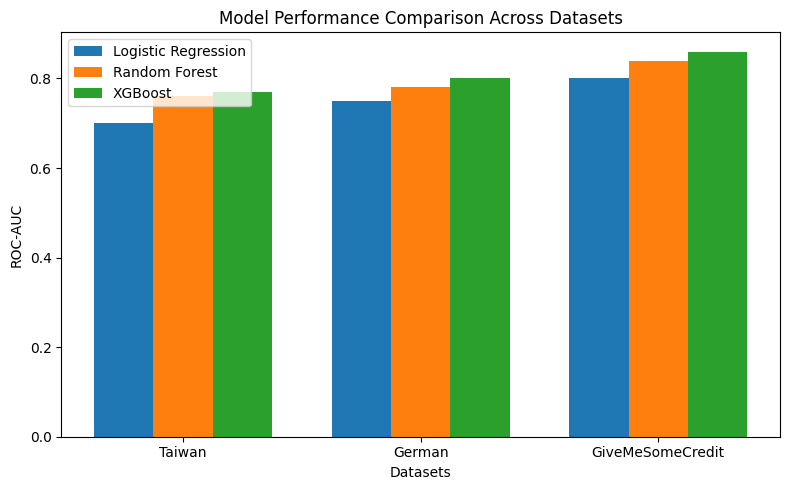

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Replace with your actual values
datasets = ['Taiwan', 'German', 'GiveMeSomeCredit']

log_reg = [0.70, 0.75, 0.80]
rf = [0.76, 0.78, 0.84]
xgb = [0.77, 0.80, 0.86]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, log_reg, width, label='Logistic Regression')
plt.bar(x, rf, width, label='Random Forest')
plt.bar(x + width, xgb, width, label='XGBoost')

plt.xlabel('Datasets')
plt.ylabel('ROC-AUC')
plt.title('Model Performance Comparison Across Datasets')
plt.xticks(x, datasets)
plt.legend()

plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=300)
plt.show()


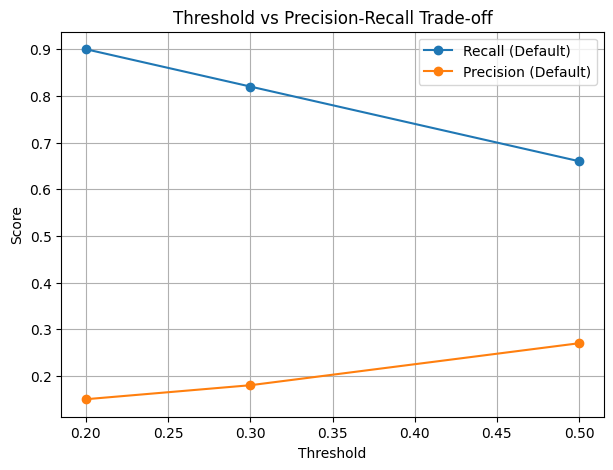

In [ ]:
thresholds = [0.5, 0.3, 0.2]

recall = [0.66, 0.82, 0.90]
precision = [0.27, 0.18, 0.15]

plt.figure(figsize=(7,5))

plt.plot(thresholds, recall, marker='o', label='Recall (Default)')
plt.plot(thresholds, precision, marker='o', label='Precision (Default)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Precision-Recall Trade-off')
plt.legend()
plt.grid(True)

plt.savefig('threshold_tradeoff.png', dpi=300)
plt.show()


In [ ]:
# 1. Train XGBoost again (Taiwan dataset)

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 2. Get probabilities
probs = xgb_model.predict_proba(X_test)[:,1]

# 3. Create risk levels
risk_level = []

for p in probs:
    if p < 0.30:
        risk_level.append("Low Risk")
    elif p < 0.60:
        risk_level.append("Medium Risk")
    else:
        risk_level.append("High Risk")

# 4. Create results dataframe
results = X_test.copy()
results["Actual"] = y_test.values
results["Default_Prob"] = probs
results["Risk_Level"] = risk_level


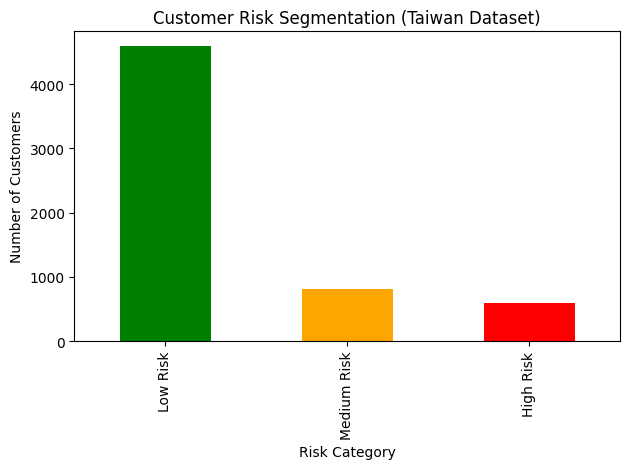

In [ ]:
import matplotlib.pyplot as plt

results['Risk_Level'].value_counts().plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title('Customer Risk Segmentation (Taiwan Dataset)')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=300)
plt.show()


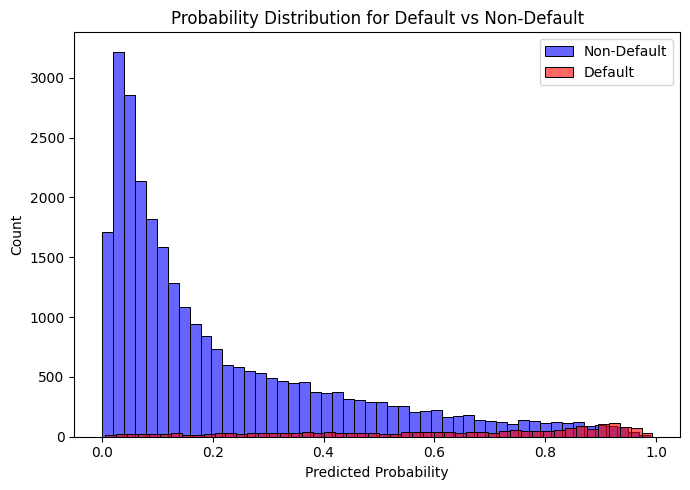

In [ ]:
import seaborn as sns

probs = xgb_k.predict_proba(X_test_k)[:,1]

plt.figure(figsize=(7,5))

sns.histplot(probs[y_test_k==0], color='blue', label='Non-Default', bins=50, alpha=0.6)
sns.histplot(probs[y_test_k==1], color='red', label='Default', bins=50, alpha=0.6)

plt.legend()
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution for Default vs Non-Default')

plt.tight_layout()
plt.savefig('probability_histogram.png', dpi=300)
plt.show()


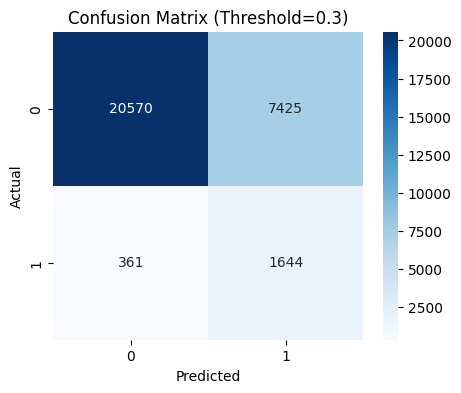

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_k, pred_30)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold=0.3)')

plt.savefig('confusion_matrix.png', dpi=300)
plt.show()


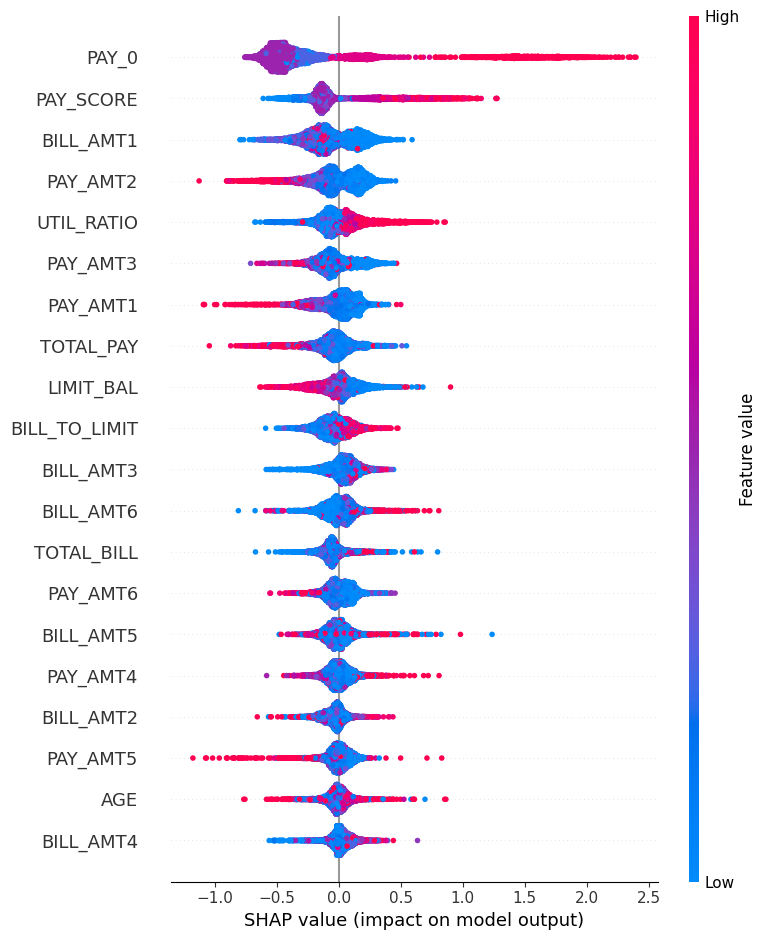

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)

plt.savefig('shap_taiwan.png', dpi=300, bbox_inches='tight')
plt.show()


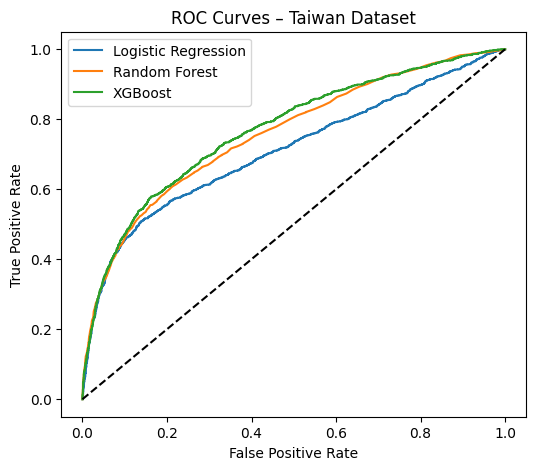

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic
probs_log = log_model.predict_proba(X_test_scaled)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, probs_log)

# Random Forest
probs_rf = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)

# XGBoost
probs_xgb = xgb_model.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, probs_xgb)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Taiwan Dataset')
plt.legend()

plt.savefig('roc_taiwan.png', dpi=300)
plt.show()
